In [ ]:
import os

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d ejlok1/cremad

!unzip -q cremad.zip -d ./crema_data
print("Download and Unzip Complete!")

Dataset URL: https://www.kaggle.com/datasets/ejlok1/cremad
License(s): ODC Attribution License (ODC-By)
100% 451M/451M [00:03<00:00, 148MB/s]

Download and Unzip Complete!


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

output_path = '/content/drive/MyDrive/CREMA-D_Processed_Features'
if not os.path.exists(output_path):
    os.makedirs(output_path)

Mounted at /content/drive


This function incorporates Silence Trimming, Pre-Emphasis, Augmentation, and Hybrid Feature Extraction.

In [ ]:
# Install the main Essentia package and Audiomentations
!pip install essentia audiomentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 20.6 MB/s eta 0:00:00
  Attempting uninstall: soxr
    Found existing installation: soxr 1.0.0
    Uninstalling soxr-1.0.0:
      Successfully uninstalled soxr-1.0.0


In [ ]:
import librosa
import numpy as np
import essentia.standard as es
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift

augmenter = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.01, p=0.4),
    TimeStretch(min_rate=0.8, max_rate=1.2, p=0.5),
    PitchShift(min_semitones=-3, max_semitones=3, p=0.5),
])

def preprocess_audio(file_path):
    #Load and Clean (Step 3: Silence Trimming)
    y, sr = librosa.load(file_path, sr=16000)
    y, _ = librosa.effects.trim(y, top_db=20)

    #Pre-Emphasis Filter
    y = librosa.effects.preemphasis(y)

    #Augmentations (Audiomentations)
    y_aug = augmenter(samples=y, sample_rate=sr)

    #Channel 1: Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=y_aug, sr=sr, n_mels=128)
    log_mel = librosa.power_to_db(mel)

    #Channel 2: MFCCs
    mfcc = librosa.feature.mfcc(y=y_aug, sr=sr, n_mfcc=40)
    #Channel 3: Pitch/HNR
    pitch_extractor = es.PredominantPitchMelodia(sampleRate=sr)
    pitch, _ = pitch_extractor(y_aug)


    return log_mel

In [ ]:
import os
from tqdm import tqdm

raw_data_path = './crema_data/AudioWAV/'
processed_drive_path = '/content/drive/MyDrive/CREMA-D_Processed_Tensors/'

if not os.path.exists(processed_drive_path):
    os.makedirs(processed_drive_path)

#list of all .wav files
audio_files = [f for f in os.listdir(raw_data_path) if f.endswith('.wav')]

print(f"Starting processing for {len(audio_files)} files...")

#Loop through and save
for file_name in tqdm(audio_files[:100]):
    file_path = os.path.join(raw_data_path, file_name)

    # Calling your function
    processed_tensor = preprocess_audio(file_path)

    #Save as a NumPy file
    save_path = os.path.join(processed_drive_path, file_name.replace('.wav', '.npy'))
    np.save(save_path, processed_tensor)

print(f"\nSuccess! Check your Google Drive folder: {processed_drive_path}")

Starting processing for 7442 files...


100%|██████████| 100/100 [00:35<00:00,  2.81it/s]


Success! Check your Google Drive folder: /content/drive/MyDrive/CREMA-D_Processed_Tensors/


To visualize the Mel-spectrogram of the very last file processed to confirm that the Silence Trimming and Pre-Emphasis worked.

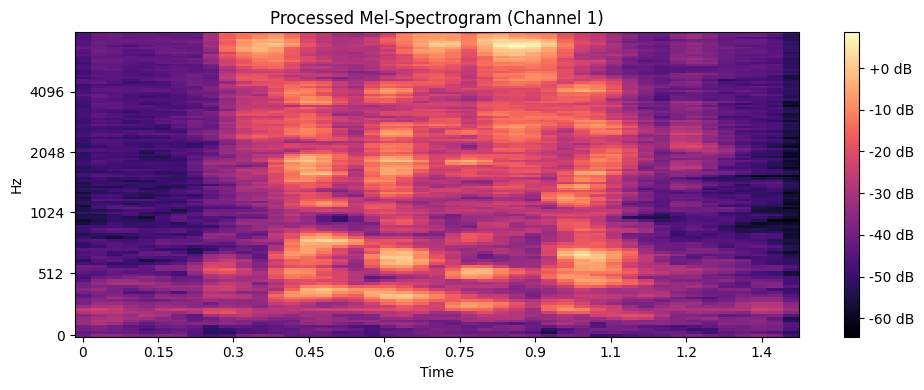

In [ ]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10, 4))
librosa.display.specshow(processed_tensor, sr=16000, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Processed Mel-Spectrogram (Channel 1)')
plt.tight_layout()
plt.show()

In [ ]:
import os
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift

RAW_DATA_PATH = './crema_data/AudioWAV/'
OUTPUT_DIR = '/content/drive/MyDrive/CREMA-D_Final_Tensors/'
METADATA_PATH = '/content/drive/MyDrive/CREMA-D_Metadata.csv'

os.makedirs(OUTPUT_DIR, exist_ok=True)

augmenter = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
    TimeStretch(min_rate=0.8, max_rate=1.2, p=0.5),
    PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
    Shift(p=0.3),
])

print("Global variables updated and version-safe! Ready to process.")

Global variables updated and version-safe! Ready to process.


To verify that your parallel workers, your augmentation pipeline, and your metadata extraction are all speaking the same language.

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import numpy as np
from tqdm import tqdm

print("Parallel tools imported! You're ready to run the check.")

Parallel tools imported! You're ready to run the check.


In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import essentia.standard as es
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

RAW_DATA_PATH = './crema_data/AudioWAV/'
OUTPUT_DIR = '/content/drive/MyDrive/CREMA-D_Final_Tensors/'
METADATA_PATH = '/content/drive/MyDrive/CREMA-D_Metadata.csv'
os.makedirs(OUTPUT_DIR, exist_ok=True)

augmenter = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
    TimeStretch(min_rate=0.8, max_rate=1.2, p=0.5),
    PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
    Shift(p=0.3),
])

def worker_task(file_name):
    try:
        #Load and Clean
        y, sr = librosa.load(os.path.join(RAW_DATA_PATH, file_name), sr=16000)
        y, _ = librosa.effects.trim(y, top_db=20)
        y = librosa.effects.preemphasis(y)

        #Standardize Length (3.0s)
        target_samples = int(3.0 * sr)
        y = np.pad(y, (0, max(0, target_samples - len(y))))[:target_samples]

        #Augment
        y_aug = augmenter(samples=y, sample_rate=sr)

        #Feature 1: Log-Mel
        mel = librosa.feature.melspectrogram(y=y_aug, sr=sr, n_mels=128)
        log_mel = librosa.power_to_db(mel, ref=np.max)

        #Feature 2: MFCC (128 to match height)
        mfcc = librosa.feature.mfcc(y=y_aug, sr=sr, n_mfcc=128)

        #Feature 3: Pitch (Essentia)
        pitch_extractor = es.PredominantPitchMelodia(sampleRate=sr)
        pitch, _ = pitch_extractor(y_aug)
        time_steps = log_mel.shape[1]
        pitch_interp = np.interp(np.linspace(0, len(pitch), time_steps), np.arange(len(pitch)), pitch)
        pitch_channel = np.tile(pitch_interp, (128, 1))

        #Stack and Normalize
        feature_stack = np.stack([log_mel, mfcc, pitch_channel], axis=0)
        feature_stack = (feature_stack - np.min(feature_stack)) / (np.max(feature_stack) - np.min(feature_stack) + 1e-6)

        save_name = file_name.replace('.wav', '.npy')
        np.save(os.path.join(OUTPUT_DIR, save_name), feature_stack.astype(np.float32))

        parts = file_name.split('_')
        return {
            "filename": save_name, "actor_id": int(parts[0]), "emotion": parts[2],
            "intensity": parts[3].split('.')[0], "status": "success"
        }
    except Exception as e:
        return {"filename": file_name, "status": "error", "message": str(e)}

print("Setup Complete! Functions and Globals are now in memory.")

Setup Complete! Functions and Globals are now in memory.


In [ ]:
test_files = audio_files[:5]
test_metadata = []
test_errors = []

print("Running Final Sanity Check on 5 files...")

with ProcessPoolExecutor(max_workers=2) as executor:
    futures = {executor.submit(worker_task, f): f for f in test_files}
    for future in tqdm(as_completed(futures), total=len(test_files)):
        res = future.result()
        if res["status"] == "success":
            test_metadata.append(res)
        else:
            test_errors.append(res)

if not test_errors:
    first_npy = os.path.join(OUTPUT_DIR, test_metadata[0]['filename'])
    sample_tensor = np.load(first_npy)

    print("\n--- TEST RESULTS ---")
    print(f"1. Tensor Shape: {sample_tensor.shape} (Expected: 3, 128, ~94)")
    print(f"2. Data Range: Min={sample_tensor.min():.2f}, Max={sample_tensor.max():.2f} (Expected: 0.0 to 1.0)")
    print(f"3. Metadata Sample: {test_metadata[0]['emotion']} intensity: {test_metadata[0]['intensity']}")
    print("\nEverything looks perfect! You are cleared for the full 7,442 file run.")
else:
    print(f"\nDetection Errors: {test_errors}")

Running Final Sanity Check on 5 files...


100%|██████████| 5/5 [00:00<00:00,  6.49it/s]


--- TEST RESULTS ---
1. Tensor Shape: (3, 128, 94) (Expected: 3, 128, ~94)
2. Data Range: Min=0.00, Max=1.00 (Expected: 0.0 to 1.0)
3. Metadata Sample: DIS intensity: XX

Everything looks perfect! You are cleared for the full 7,442 file run.


In [ ]:
import numpy as np
import librosa
import essentia.standard as es

def process_single_file(file_name, target_duration=3.0):

    full_path = os.path.join(RAW_DATA_PATH, file_name)

    y, sr = librosa.load(full_path, sr=16000)
    y, _ = librosa.effects.trim(y, top_db=20)
    y = librosa.effects.preemphasis(y)

    #Standardize Length (Padding/Truncating to exactly 3.0 seconds)
    target_samples = int(target_duration * sr)
    if len(y) < target_samples:
        y = np.pad(y, (0, target_samples - len(y)), mode='constant')
    else:
        y = y[:target_samples]

    #Apply Augmentations
    y_aug = augmenter(samples=y, sample_rate=sr)

    #Channel 1: Mel Spectrogram
    mel = librosa.feature.melspectrogram(y=y_aug, sr=sr, n_mels=128, fmax=8000)
    log_mel = librosa.power_to_db(mel, ref=np.max)

    #Channel 2: MFCCs
    mfcc = librosa.feature.mfcc(y=y_aug, sr=sr, n_mfcc=128)

    #Channel 3: Essentia Pitch (Melodia algorithm)
    pitch_extractor = es.PredominantPitchMelodia(sampleRate=sr)
    pitch, _ = pitch_extractor(y_aug)

    #Resize Pitch
    time_steps = log_mel.shape[1]
    pitch_interp = np.interp(
        np.linspace(0, len(pitch), time_steps),
        np.arange(len(pitch)),
        pitch
    )

    pitch_channel = np.tile(pitch_interp, (128, 1))

    feature_stack = np.stack([log_mel, mfcc, pitch_channel], axis=0)
    denom = np.max(feature_stack) - np.min(feature_stack)
    feature_stack = (feature_stack - np.min(feature_stack)) / (denom + 1e-6)

    return feature_stack.astype(np.float32)

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import essentia.standard as es
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

RAW_DATA_PATH = './crema_data/AudioWAV/'
OUTPUT_DIR = '/content/drive/MyDrive/CREMA-D_Final_Tensors/'
METADATA_PATH = '/content/drive/MyDrive/CREMA-D_Metadata.csv'
os.makedirs(OUTPUT_DIR, exist_ok=True)

augmenter = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
    TimeStretch(min_rate=0.8, max_rate=1.2, p=0.5),
    PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
    Shift(p=0.3),
])

def worker_task(file_name):

    try:
        full_path = os.path.join(RAW_DATA_PATH, file_name)

        #Load and Clean
        y, sr = librosa.load(full_path, sr=16000)
        y, _ = librosa.effects.trim(y, top_db=20)
        y = librosa.effects.preemphasis(y)

        #Standardize Length (3.0s)
        target_samples = int(3.0 * sr)
        if len(y) < target_samples:
            y = np.pad(y, (0, target_samples - len(y)), mode='constant')
        else:
            y = y[:target_samples]

        #Augment
        y_aug = augmenter(samples=y, sample_rate=sr)

        # Channel 1: Log-Mel
        mel = librosa.feature.melspectrogram(y=y_aug, sr=sr, n_mels=128)
        log_mel = librosa.power_to_db(mel, ref=np.max)

        # Channel 2: MFCC
        mfcc = librosa.feature.mfcc(y=y_aug, sr=sr, n_mfcc=128)

        # Channel 3: Pitch (Essentia)
        pitch_extractor = es.PredominantPitchMelodia(sampleRate=sr)
        pitch, _ = pitch_extractor(y_aug)
        time_steps = log_mel.shape[1]
        pitch_interp = np.interp(np.linspace(0, len(pitch), time_steps), np.arange(len(pitch)), pitch)
        pitch_channel = np.tile(pitch_interp, (128, 1))

        #Stack and Normalize
        feature_stack = np.stack([log_mel, mfcc, pitch_channel], axis=0)
        denom = np.max(feature_stack) - np.min(feature_stack)
        feature_stack = (feature_stack - np.min(feature_stack)) / (denom + 1e-6)

        #Save .npy File
        save_name = file_name.replace('.wav', '.npy')
        np.save(os.path.join(OUTPUT_DIR, save_name), feature_stack.astype(np.float32))

        parts = file_name.split('_')
        return {
            "filename": save_name,
            "actor_id": int(parts[0]),
            "sentence": parts[1],
            "emotion": parts[2],
            "intensity": parts[3].split('.')[0],
            "status": "success"
        }
    except Exception as e:
        return {"filename": file_name, "status": "error", "message": str(e)}

audio_files = [f for f in os.listdir(RAW_DATA_PATH) if f.endswith('.wav')]
metadata_list = []
errors = []

print(f" Starting parallel processing for {len(audio_files)} files...")

with ProcessPoolExecutor() as executor:
    futures = {executor.submit(worker_task, f): f for f in audio_files}

    for future in tqdm(as_completed(futures), total=len(audio_files)):
        result = future.result()
        if result["status"] == "success":
            metadata_list.append(result)
        else:
            errors.append(result)

df = pd.DataFrame(metadata_list)
df.to_csv(METADATA_PATH, index=False)

print(f"\n✅ DONE!")
print(f"Successfully saved {len(metadata_list)} tensors to {OUTPUT_DIR}")
print(f"Metadata saved to {METADATA_PATH}")

if errors:
    print(f"⚠️ Warning: {len(errors)} files failed. Check 'errors' variable.")

 Starting parallel processing for 7442 files...


100%|██████████| 7442/7442 [21:50<00:00,  5.68it/s]


✅ DONE!
Successfully saved 7442 tensors to /content/drive/MyDrive/CREMA-D_Final_Tensors/
Metadata saved to /content/drive/MyDrive/CREMA-D_Metadata.csv


This code snippet is to see if your dataset is "balanced." In Emotion Recognition, we want to make sure we have enough examples of each emotion so the model doesn't become biased.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/CREMA-D_Metadata.csv')

print("--- Emotion Distribution ---")
print(df['emotion'].value_counts())

print("\n--- Metadata Preview ---")
print(df.head())

--- Emotion Distribution ---
emotion
SAD    1271
DIS    1271
FEA    1271
HAP    1271
ANG    1271
NEU    1087
Name: count, dtype: int64

--- Metadata Preview ---
              filename  actor_id sentence emotion intensity   status
0  1010_DFA_SAD_XX.npy      1010      DFA     SAD        XX  success
1  1066_IWW_DIS_XX.npy      1066      IWW     DIS        XX  success
2  1036_IOM_FEA_XX.npy      1036      IOM     FEA        XX  success
3  1027_IEO_SAD_LO.npy      1027      IEO     SAD        LO  success
4  1019_WSI_HAP_XX.npy      1019      WSI     HAP        XX  success


In [ ]:
import os
print(os.path.exists('/content/drive/MyDrive/CREMA-D_Metadata.csv'))

True


This lists the first 10 files in your Google Drive folder

In [ ]:
import os
files = os.listdir('/content/drive/MyDrive/CREMA-D_Final_Tensors/')
print(f"Total files found: {len(files)}")
print(f"First 10 files: {files[:10]}")

Total files found: 7442
First 10 files: ['1066_IWW_DIS_XX.npy', '1010_DFA_SAD_XX.npy', '1027_IEO_SAD_LO.npy', '1036_IOM_FEA_XX.npy', '1019_WSI_HAP_XX.npy', '1066_ITH_DIS_XX.npy', '1017_IWL_ANG_XX.npy', '1017_IWW_FEA_XX.npy', '1050_IWL_HAP_XX.npy', '1032_ITS_NEU_XX.npy']


### DATA PIPELINE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import os

In [ ]:
metadata_path = '/content/drive/MyDrive/CREMA-D_Metadata.csv'
base_tensor_path = '/content/drive/MyDrive/CREMA-D_Final_Tensors'

In [ ]:
!ls /content/drive/MyDrive/CREMA-D_Metadata.csv

/content/drive/MyDrive/CREMA-D_Metadata.csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

#Loading master index
metadata_path = '/content/drive/MyDrive/CREMA-D_Metadata.csv'
df = pd.read_csv(metadata_path)

train_df, rest_df = train_test_split(df, test_size=0.2, stratify=df['emotion'], random_state=42)

val_df, test_df = train_test_split(rest_df, test_size=0.5, stratify=rest_df['emotion'], random_state=42)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Testing samples: {len(test_df)}")

Training samples: 5953
Validation samples: 744
Testing samples: 745


In [ ]:
class CREMADataGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, base_path, batch_size=32, shuffle=True, **kwargs):
        super().__init__(**kwargs)
        self.df = dataframe
        self.base_path = base_path
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.labels = {'SAD':0, 'ANG':1, 'HAP':2, 'FEA':3, 'DIS':4, 'NEU':5}
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __getitem__(self, index):
        batch_df = self.df[index*self.batch_size : (index+1)*self.batch_size]
        X, y = [], []
        for _, row in batch_df.iterrows():
            file_path = f"{self.base_path}/{row['filename']}"
            tensor = np.load(file_path)
            tensor = np.transpose(tensor, (1, 2, 0))
            X.append(tensor)
            y.append(self.labels[row['emotion']])
        return np.array(X), np.array(y)

In [ ]:
from tensorflow.keras import layers, models

def build_emotion_model(input_shape=(128, 100, 3)):
    model = models.Sequential(name="CNN_LSTM_Flexible_Net")

    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Reshape((-1, 128 * (128 // 8))))

    #LSTM for temporal patterns
    model.add(layers.LSTM(128, return_sequences=False))
    model.add(layers.Dropout(0.4))

    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(6, activation='softmax'))

    return model
model = build_emotion_model()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN_LSTM_Flexible_Net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 128, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 12, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │     1,114,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217,414 (4.64 MB)

 Trainable params: 1,216,966 (4.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint('/content/drive/MyDrive/best_emotion_model.h5',
                             monitor='val_accuracy',
                             save_best_only=True)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.2032 - loss: 1.8171

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


186/186 ━━━━━━━━━━━━━━━━━━━━ 1612s 9s/step - accuracy: 0.2078 - loss: 1.7944 - val_accuracy: 0.1698 - val_loss: 1.8283
Epoch 2/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.2327 - loss: 1.7683

186/186 ━━━━━━━━━━━━━━━━━━━━ 27s 143ms/step - accuracy: 0.2230 - loss: 1.7742 - val_accuracy: 0.1997 - val_loss: 1.7925
Epoch 3/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.2337 - loss: 1.7417

186/186 ━━━━━━━━━━━━━━━━━━━━ 25s 134ms/step - accuracy: 0.2389 - loss: 1.7400 - val_accuracy: 0.2310 - val_loss: 1.7472
Epoch 4/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.2689 - loss: 1.7141

186/186 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step - accuracy: 0.2629 - loss: 1.7166 - val_accuracy: 0.2745 - val_loss: 1.7054
Epoch 5/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.2656 - loss: 1.7002 - val_accuracy: 0.1902 - val_loss: 1.7820
Epoch 6/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 24s 130ms/step - accuracy: 0.2676 - loss: 1.7035 - val_accuracy: 0.2745 - val_loss: 1.6885
Epoch 7/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 24s 128ms/step - accuracy: 0.2831 - loss: 1.6871 - val_accuracy: 0.2269 - val_loss: 1.8264
Epoch 8/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 24s 127ms/step - accuracy: 0.2903 - loss: 1.6749 - val_accuracy: 0.1848 - val_loss: 1.9043
Epoch 9/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 24s 129ms/step - accuracy: 0.2913 - loss: 1.6698 - val_accuracy: 0.2636 - val_loss: 1.7052
Epoch 10/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - accuracy: 0.3110 - loss: 1.6493 - val_accuracy: 0.2446 - val_loss: 1.7410
Epoch 11/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 23s 124ms/step - accuracy: 0.3038 - loss: 1.6434 - v

186/186 ━━━━━━━━━━━━━━━━━━━━ 24s 129ms/step - accuracy: 0.3085 - loss: 1.6282 - val_accuracy: 0.3057 - val_loss: 1.6382
Epoch 13/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.3278 - loss: 1.5992 - val_accuracy: 0.2989 - val_loss: 1.7005
Epoch 14/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 24s 127ms/step - accuracy: 0.3335 - loss: 1.5913 - val_accuracy: 0.2079 - val_loss: 2.0746
Epoch 15/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 23s 125ms/step - accuracy: 0.3379 - loss: 1.5950 - val_accuracy: 0.2568 - val_loss: 1.8354
Epoch 16/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 24s 127ms/step - accuracy: 0.3451 - loss: 1.5691 - val_accuracy: 0.2812 - val_loss: 1.6717
Epoch 17/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 24s 127ms/step - accuracy: 0.3480 - loss: 1.5671 - val_accuracy: 0.2541 - val_loss: 1.6777


### NEW MODEL

In [ ]:
from tensorflow.keras import layers, models, Input

def residual_block(x, filters):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_resnet_lstm_model(input_shape=(128, 94, 3)):
    inputs = Input(shape=input_shape)


    x = layers.Conv2D(64, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)


    x = residual_block(x, 64)
    x = layers.MaxPooling2D((2, 2))(x)


    x = residual_block(x, 64)
    x = layers.MaxPooling2D((2, 2))(x)


    x = layers.Reshape((23, -1))(x)

    # Bidirectional LSTM
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(6, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="ResNet_LSTM_Final_Fixed")
    return model

model = build_resnet_lstm_model()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "ResNet_LSTM_Final_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 128, 94,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 128, 94,   │      1,792 │ input_layer_7[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 94,   │        256 │ conv2d_25[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 128, 94,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 128, 94,   │     36,928 │ activation_15[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 94,   │        256 │ conv2d_26[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 128, 94,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 128, 94,   │     36,928 │ activation_16[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 94,   │        256 │ conv2d_27[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 128, 94,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │ activation_15[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_17       │ (None, 128, 94,   │          0 │ add_6[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 64, 47,    │          0 │ activation_17[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 64, 47,    │     36,928 │ max_pooling2d_16… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 47,    │        256 │ conv2d_28[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 64, 47,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 64, 47,    │     36,928 │ activation_18[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 47,    │        256 │ conv2d_29[0][0] 

 Total params: 2,414,214 (9.21 MB)

 Trainable params: 2,413,318 (9.21 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

checkpoint = ModelCheckpoint('/content/drive/MyDrive/ResNet_Emotion_Best.h5',
                             monitor='val_accuracy',
                             save_best_only=True,
                             verbose=1)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    callbacks=[lr_reducer, early_stop, checkpoint]
)

Epoch 1/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.1753 - loss: 2.2434
Epoch 1: val_accuracy improved from None to 0.17120, saving model to /content/drive/MyDrive/ResNet_Emotion_Best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/ResNet_Emotion_Best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 36s 161ms/step - accuracy: 0.1705 - loss: 2.0837 - val_accuracy: 0.1712 - val_loss: 1.8241 - learning_rate: 0.0010
Epoch 2/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.1834 - loss: 1.8638
Epoch 2: val_accuracy improved from 0.17120 to 0.21603, saving model to /content/drive/MyDrive/ResNet_Emotion_Best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/ResNet_Emotion_Best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 32s 169ms/step - accuracy: 0.1801 - loss: 1.8641 - val_accuracy: 0.2160 - val_loss: 1.7824 - learning_rate: 0.0010
Epoch 3/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.1735 - loss: 1.8441
Epoch 3: val_accuracy improved from 0.21603 to 0.24185, saving model to /content/drive/MyDrive/ResNet_Emotion_Best.h5



Epoch 3: finished saving model to /content/drive/MyDrive/ResNet_Emotion_Best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 40s 166ms/step - accuracy: 0.1788 - loss: 1.8409 - val_accuracy: 0.2418 - val_loss: 1.7743 - learning_rate: 0.0010
Epoch 4/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.1877 - loss: 1.8243
Epoch 4: val_accuracy did not improve from 0.24185
186/186 ━━━━━━━━━━━━━━━━━━━━ 30s 160ms/step - accuracy: 0.1857 - loss: 1.8259 - val_accuracy: 0.1780 - val_loss: 1.7991 - learning_rate: 0.0010
Epoch 5/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.1881 - loss: 1.8151
Epoch 5: val_accuracy did not improve from 0.24185
186/186 ━━━━━━━━━━━━━━━━━━━━ 29s 156ms/step - accuracy: 0.1917 - loss: 1.8142 - val_accuracy: 0.1698 - val_loss: 1.7795 - learning_rate: 0.0010
Epoch 6/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.1944 - loss: 1.8050
Epoch 6: val_accuracy did not improve from 0.24185
186/186 ━━━━━━━━━━━━━━━━━━━━ 29s 155ms/step - accuracy: 0.1962 - loss:


Epoch 14: finished saving model to /content/drive/MyDrive/ResNet_Emotion_Best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 30s 162ms/step - accuracy: 0.2675 - loss: 1.7114 - val_accuracy: 0.2785 - val_loss: 1.7160 - learning_rate: 5.0000e-04
Epoch 15/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.2853 - loss: 1.6661
Epoch 15: val_accuracy improved from 0.27853 to 0.29755, saving model to /content/drive/MyDrive/ResNet_Emotion_Best.h5


...


Epoch 28: finished saving model to /content/drive/MyDrive/ResNet_Emotion_Best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 30s 163ms/step - accuracy: 0.3421 - loss: 1.5600 - val_accuracy: 0.3832 - val_loss: 1.4991 - learning_rate: 1.2500e-04
Epoch 29/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.3571 - loss: 1.5541
Epoch 29: val_accuracy did not improve from 0.38315
186/186 ━━━━━━━━━━━━━━━━━━━━ 30s 158ms/step - accuracy: 0.3558 - loss: 1.5520 - val_accuracy: 0.3356 - val_loss: 1.5442 - learning_rate: 1.2500e-04
Epoch 30/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.3419 - loss: 1.5630
Epoch 30: val_accuracy did not improve from 0.38315
186/186 ━━━━━━━━━━━━━━━━━━━━ 29s 155ms/step - accuracy: 0.3522 - loss: 1.5512 - val_accuracy: 0.3438 - val_loss: 1.5771 - learning_rate: 1.2500e-04
Epoch 31/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.3689 - loss: 1.5468
Epoch 31: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 31: val_accuracy did


Epoch 36: finished saving model to /content/drive/MyDrive/ResNet_Emotion_Best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 30s 162ms/step - accuracy: 0.3627 - loss: 1.5248 - val_accuracy: 0.3967 - val_loss: 1.4738 - learning_rate: 3.1250e-05
Epoch 37/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.3613 - loss: 1.5257
Epoch 37: val_accuracy improved from 0.39674 to 0.39946, saving model to /content/drive/MyDrive/ResNet_Emotion_Best.h5



Epoch 37: finished saving model to /content/drive/MyDrive/ResNet_Emotion_Best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 31s 166ms/step - accuracy: 0.3646 - loss: 1.5310 - val_accuracy: 0.3995 - val_loss: 1.4689 - learning_rate: 3.1250e-05
Epoch 38/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.3539 - loss: 1.5439
Epoch 38: val_accuracy improved from 0.39946 to 0.40625, saving model to /content/drive/MyDrive/ResNet_Emotion_Best.h5



Epoch 38: finished saving model to /content/drive/MyDrive/ResNet_Emotion_Best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 41s 168ms/step - accuracy: 0.3678 - loss: 1.5341 - val_accuracy: 0.4062 - val_loss: 1.4734 - learning_rate: 3.1250e-05
Epoch 39/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.3673 - loss: 1.5415
Epoch 39: val_accuracy did not improve from 0.40625
186/186 ━━━━━━━━━━━━━━━━━━━━ 30s 161ms/step - accuracy: 0.3646 - loss: 1.5312 - val_accuracy: 0.3736 - val_loss: 1.4760 - learning_rate: 3.1250e-05
Epoch 40/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.3722 - loss: 1.5356
Epoch 40: val_accuracy did not improve from 0.40625
186/186 ━━━━━━━━━━━━━━━━━━━━ 29s 154ms/step - accuracy: 0.3715 - loss: 1.5272 - val_accuracy: 0.4008 - val_loss: 1.4632 - learning_rate: 3.1250e-05
Epoch 41/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.3719 - loss: 1.5182
Epoch 41: val_accuracy improved from 0.40625 to 0.41440, saving model to /content/drive/MyDrive/ResNet_


Epoch 41: finished saving model to /content/drive/MyDrive/ResNet_Emotion_Best.h5
186/186 ━━━━━━━━━━━━━━━━━━━━ 30s 161ms/step - accuracy: 0.3595 - loss: 1.5303 - val_accuracy: 0.4144 - val_loss: 1.4661 - learning_rate: 3.1250e-05
Epoch 42/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.3650 - loss: 1.5285
Epoch 42: val_accuracy did not improve from 0.41440
186/186 ━━━━━━━━━━━━━━━━━━━━ 29s 157ms/step - accuracy: 0.3644 - loss: 1.5275 - val_accuracy: 0.4022 - val_loss: 1.4858 - learning_rate: 3.1250e-05
Epoch 43/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.3634 - loss: 1.5270
Epoch 43: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 43: val_accuracy did not improve from 0.41440
186/186 ━━━━━━━━━━━━━━━━━━━━ 29s 155ms/step - accuracy: 0.3686 - loss: 1.5178 - val_accuracy: 0.3940 - val_loss: 1.4718 - learning_rate: 3.1250e-05
Epoch 44/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.3694 - loss: 1.5325
Epoch 44: val_accuracy d

### Attempt to increase accuracy more

In [ ]:
import numpy as np
import tensorflow as tf

class CREMAProGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, base_path, batch_size=32, shuffle=True, augment=False, **kwargs):
        super().__init__(**kwargs)
        self.df = dataframe
        self.base_path = base_path
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.labels = {'SAD':0, 'ANG':1, 'HAP':2, 'FEA':3, 'DIS':4, 'NEU':5}
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __getitem__(self, index):
        batch_df = self.df[index*self.batch_size : (index+1)*self.batch_size]
        X, y = [], []

        for _, row in batch_df.iterrows():

            tensor = np.load(f"{self.base_path}/{row['filename']}")

            tensor = np.transpose(tensor, (1, 2, 0))

            if self.augment:

                f_width = np.random.randint(0, 8)
                f_start = np.random.randint(0, 128 - f_width)
                tensor[f_start:f_start+f_width, :, :] = 0


                t_width = np.random.randint(0, 6)
                t_start = np.random.randint(0, 94 - t_width)
                tensor[:, t_start:t_start+t_width, :] = 0

            X.append(tensor)
            y.append(self.labels[row['emotion']])

        return np.array(X), np.array(y)

train_gen = CREMAProGenerator(train_df, base_tensor_path, augment=True, shuffle=True)
val_gen = CREMAProGenerator(val_df, base_tensor_path, augment=False, shuffle=False)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-7, verbose=1)

early_stop = EarlyStopping(monitor='val_accuracy', mode='max', patience=12, restore_best_weights=True)

checkpoint = ModelCheckpoint('/content/drive/MyDrive/CREMA_60Percent_Push.keras',
                             monitor='val_accuracy',
                             save_best_only=True,
                             verbose=1)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=100,
    callbacks=[lr_reducer, early_stop, checkpoint]
)

Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.3452 - loss: 1.5847
Epoch 1: val_accuracy improved from None to 0.36957, saving model to /content/drive/MyDrive/CREMA_60Percent_Push.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CREMA_60Percent_Push.keras
186/186 ━━━━━━━━━━━━━━━━━━━━ 29s 156ms/step - accuracy: 0.3468 - loss: 1.5730 - val_accuracy: 0.3696 - val_loss: 1.4952 - learning_rate: 7.8125e-06
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.3640 - loss: 1.5520
Epoch 2: val_accuracy did not improve from 0.36957
186/186 ━━━━━━━━━━━━━━━━━━━━ 30s 159ms/step - accuracy: 0.3545 - loss: 1.5649 - val_accuracy: 0.3560 - val_loss: 1.5138 - learning_rate: 7.8125e-06
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.3595 - loss: 1.5488
Epoch 3: val_accuracy improved from 0.36957 to 0.37908, saving model to /content/drive/MyDrive/CREMA_60Percent_Push.keras

Epoch 3: finished saving model to /content/drive/MyDrive/CR

### Feature Concatenation Strategy

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('swish')(x)
    return x

def build_u_of_t_fusion_model(input_shape=(128, 94, 3)):
    inputs = Input(shape=input_shape)

    #BRANCH 1: Spatial/Texture Extraction (CNN)
    cnn = layers.Conv2D(64, (3, 3), padding='same')(inputs)
    cnn = layers.BatchNormalization()(cnn)
    cnn = layers.Activation('swish')(cnn)
    cnn = residual_block(cnn, 64)
    cnn = layers.MaxPooling2D((2, 2))(cnn) # (64, 47, 64)

    cnn = residual_block(cnn, 64)
    cnn = layers.GlobalAveragePooling2D()(cnn) # Flattens to 64 features

    #BRANCH 2: Temporal/Prosody Extraction (LSTM)
    temporal = layers.Reshape((94, -1))(inputs)
    temporal = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(temporal)
    temporal = layers.GlobalMaxPooling1D()(temporal) # Captures the strongest emotional peaks

    #FUSION
    #Concatenate the Texture (CNN) and the Rhythm (LSTM)
    combined = layers.concatenate([cnn, temporal])

    x = layers.Dense(256, activation='swish')(combined)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='swish')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(6, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="Feature_Fusion_60Percent_Goal")
    return model

model = build_u_of_t_fusion_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

initial_learning_rate = 1e-3
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate, decay_steps=10000)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

checkpoint = ModelCheckpoint('/content/drive/MyDrive/Fusion_Model_Best.keras',
                             monitor='val_accuracy',
                             save_best_only=True,
                             mode='max',
                             verbose=1)

early_stop = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=100,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 28s/step - accuracy: 0.1873 - loss: 2.0746 
Epoch 1: val_accuracy improved from None to 0.20109, saving model to /content/drive/MyDrive/Fusion_Model_Best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Fusion_Model_Best.keras
186/186 ━━━━━━━━━━━━━━━━━━━━ 5964s 32s/step - accuracy: 0.1909 - loss: 1.9642 - val_accuracy: 0.2011 - val_loss: 1.7982
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.2453 - loss: 1.7877
Epoch 2: val_accuracy improved from 0.20109 to 0.21875, saving model to /content/drive/MyDrive/Fusion_Model_Best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Fusion_Model_Best.keras
186/186 ━━━━━━━━━━━━━━━━━━━━ 39s 208ms/step - accuracy: 0.2559 - loss: 1.7501 - val_accuracy: 0.2188 - val_loss: 1.7688
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.3033 - loss: 1.6637
Epoch 3: val_accuracy did not improve from 0.21875
186/186 ━━━━━━━━━━━━━━━━━━━━ 36s 194ms/step 

#More tunning

In [ ]:
# Re-compile with Gradient Clipping and Label Smoothing
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4,
        clipnorm=1.0
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
    ),
    metrics=['accuracy']
)

def lr_schedule(epoch):
    if epoch < 10: return 1e-4
    if epoch < 30: return 5e-4
    return 1e-5

lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_schedule)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    initial_epoch=53,
    callbacks=[checkpoint, early_stop, lr_callback]
)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_robust_60_model(input_shape=(128, 94, 3)):
    inputs = layers.Input(shape=input_shape)


    x = layers.LayerNormalization()(inputs)

    #Branch 1: The CNN (Texture)
    cnn = layers.Conv2D(64, (3, 3), padding='same', activation='swish')(x)
    cnn = layers.SpatialDropout2D(0.2)(cnn) # Drop random frequency bands
    cnn = layers.MaxPooling2D((2, 2))(cnn)

    cnn = layers.Conv2D(128, (3, 3), padding='same', activation='swish')(cnn)
    cnn = layers.GlobalAveragePooling2D()(cnn)

    #Branch 2: The LSTM
    temporal = layers.Reshape((94, 128*3))(x)
    temporal = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(temporal)

    combined = layers.concatenate([cnn, temporal])

    x = layers.Dense(256, activation='swish')(combined)
    x = layers.Dropout(0.5)(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Dense(6, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model


model = build_robust_60_model()

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
import math

def scheduler(epoch, lr):
    if epoch < 15:
        return float(lr)
    else:
        return float(lr * math.exp(-0.1))

lr_callback = tf.keras.callbacks.LearningRateScheduler(scheduler)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    initial_epoch=15,
    callbacks=[checkpoint, lr_callback]
)

Epoch 16/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 27s 147ms/step - accuracy: 0.3332 - loss: 1.6093 - val_accuracy: 0.3329 - val_loss: 1.5550 - learning_rate: 9.0484e-05
Epoch 17/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 27s 145ms/step - accuracy: 0.3365 - loss: 1.6011 - val_accuracy: 0.3234 - val_loss: 1.5709 - learning_rate: 8.1873e-05
Epoch 18/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - accuracy: 0.3402 - loss: 1.5828 - val_accuracy: 0.3601 - val_loss: 1.5472 - learning_rate: 7.4082e-05
Epoch 19/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - accuracy: 0.3382 - loss: 1.5743 - val_accuracy: 0.3519 - val_loss: 1.5451 - learning_rate: 6.7032e-05
Epoch 20/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - accuracy: 0.3611 - loss: 1.5562 - val_accuracy: 0.3003 - val_loss: 1.5974 - learning_rate: 6.0653e-05
Epoch 21/50
186/186 ━━━━━━━━━━━━━━━━━━━━ 26s 142ms/step - accuracy: 0.3498 - loss: 1.5598 - val_accuracy: 0.3614 - val_loss: 1.5256 - learning_rate: 5.4881e-05
Epoch 22/50
186/186 ━━━━━━━━━━━━━━━━━━━━